In [1]:
from notebook_utils import run_sdp_on_range, plot_robustness, plot_schmidt_number, bin_search_sdp_vertex
import numpy as np

# Test on $\mathbb{C}^2 \otimes \mathbb{C}^2$ isotropic state

0it [00:00, ?it/s]


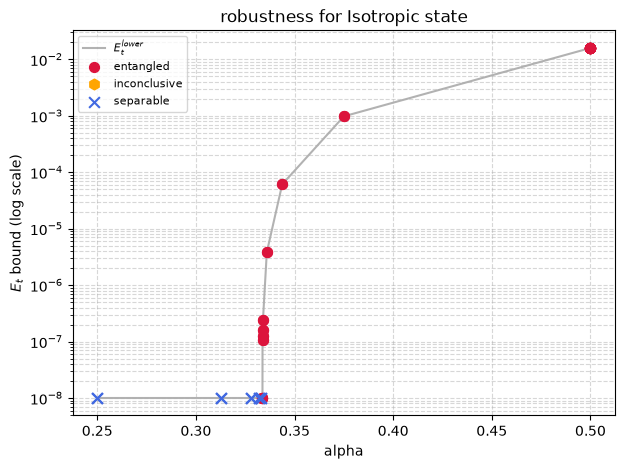

In [2]:
from toqito.states import isotropic

filename = "c2c2_Isotropic.jsonl"
bin_search_sdp_vertex(filename, (2, 2), [1, 1], lambda p: isotropic(2, p), (0, 1), 30, folder="test")
plot_robustness(filename, "robustness for Isotropic state", "alpha", folder="test")

# Test on $\mathbb{C}^3 \otimes \mathbb{C}^3$ states with noise and on Horodecki

In [3]:
from bound_entangled.c3_otimes_c3 import chessboard_extremal_PPT, cross_hatch, tiles_upb, pyramid_upb, horodecki, ncomms6297, steering_state
from toqito.states import max_mixed

## Horodecki state

0 points left to compute


0it [00:00, ?it/s]

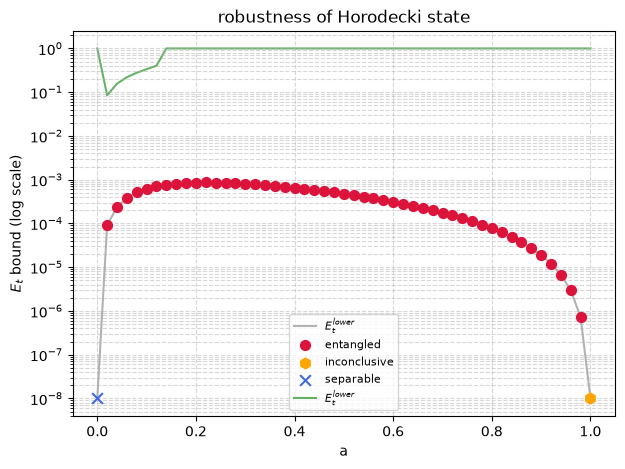

In [4]:
filename = "c3c3_Horodecki.jsonl"
range_ = (0, 1, 0.02)
run_sdp_on_range(filename, (3, 3), [1, 1], lambda p: horodecki(p), range_, compute_upper=True, folder="Parametric")
plot_robustness(filename, "robustness of Horodecki state", "a", range_=range_, plot_upper=True, folder="Parametric")

## States with added noise

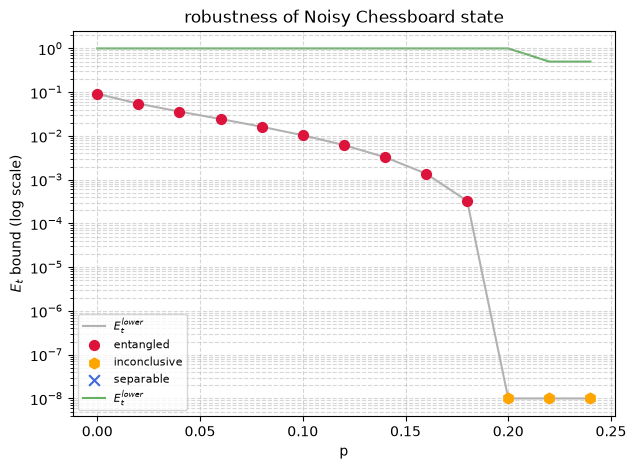

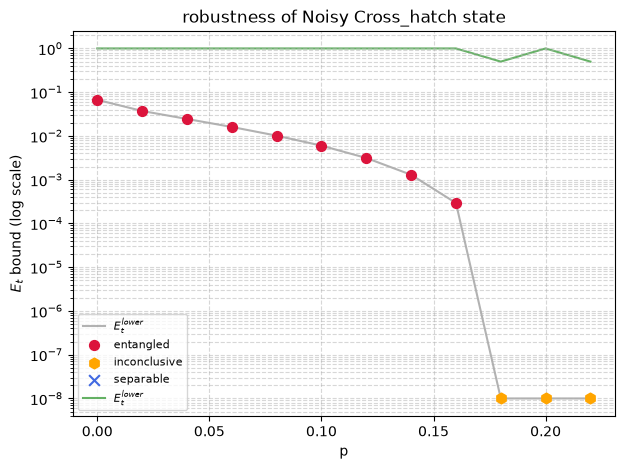

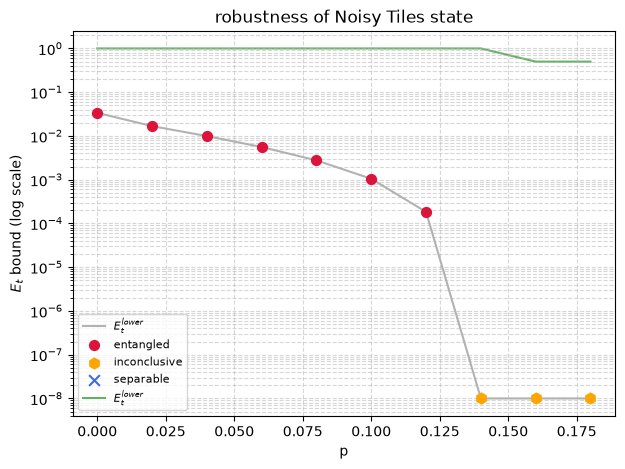

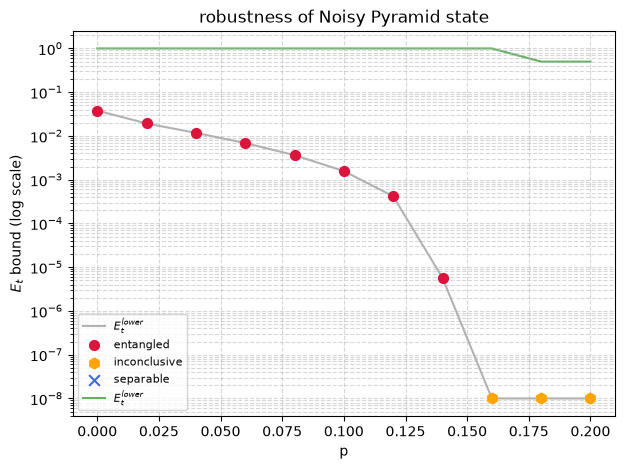

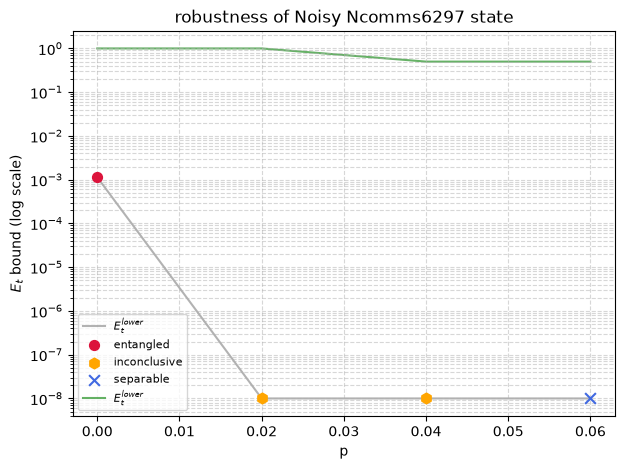

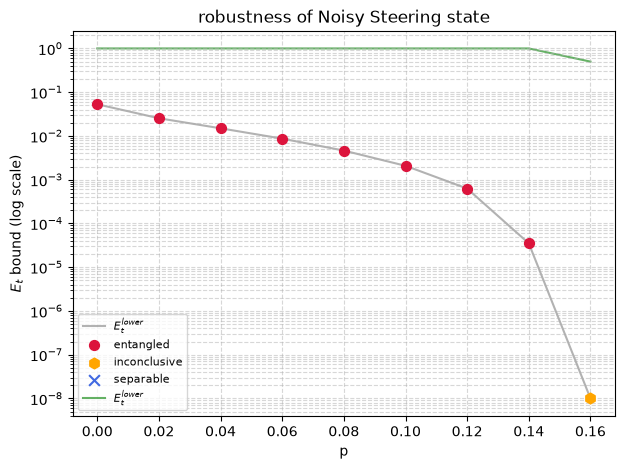

In [5]:
c3c3_non_parametric = [
    (chessboard_extremal_PPT(), "Chessboard"),
    (cross_hatch(), "Cross_hatch"),
    (tiles_upb(), "Tiles"),
    (pyramid_upb(), "Pyramid"),
    (ncomms6297(), "Ncomms6297"),
    (steering_state(0.4, 0.4), "Steering"),
]
maxmixed = max_mixed(3 * 3)

for state, name in c3c3_non_parametric:
    filename = f"{name}_with_noise.jsonl"
    run_sdp_on_range(filename, (3, 3), [1, 1], lambda p: state * (1 - p) + maxmixed * p, range_, compute_upper=True, early_stop=True, folder="noise")
    plot_robustness(filename, f"robustness of Noisy {name} state", "p", range_=range_, plot_upper=True, folder="noise")

0it [00:00, ?it/s]


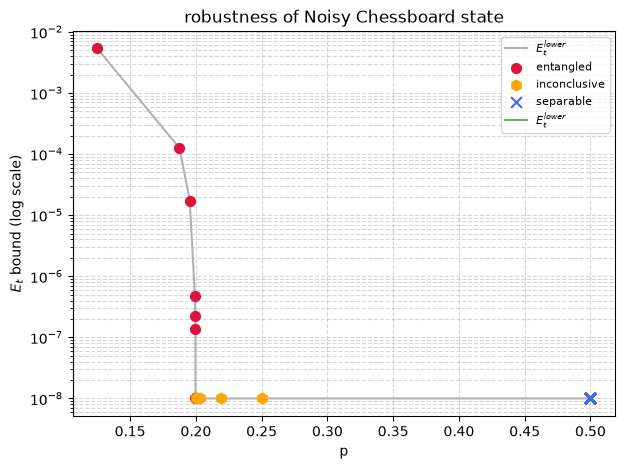

0it [00:00, ?it/s]


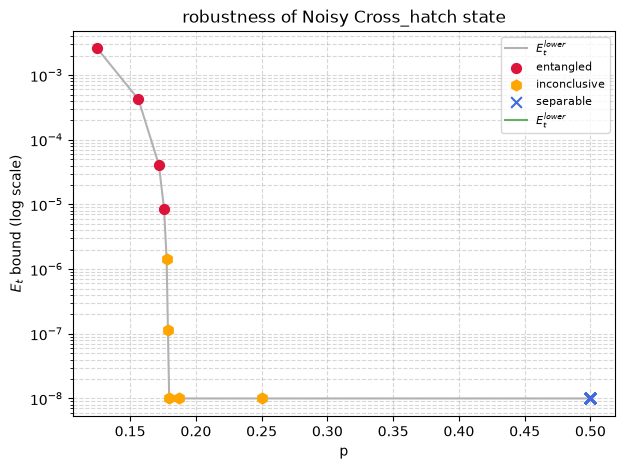

0it [00:00, ?it/s]


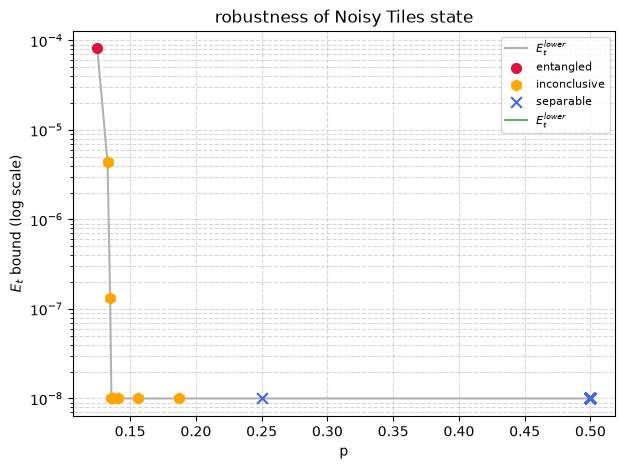

0it [00:00, ?it/s]


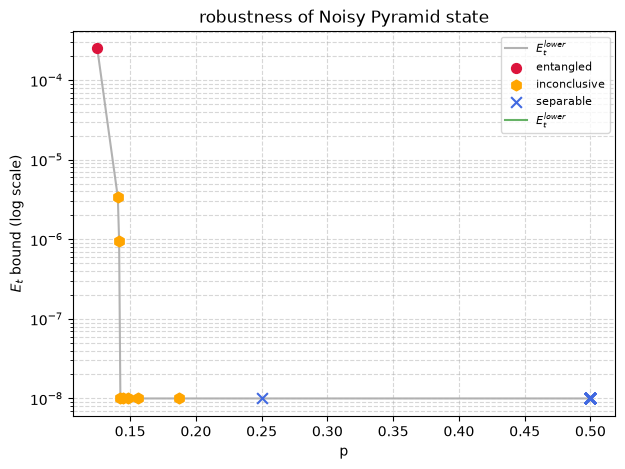

0it [00:00, ?it/s]


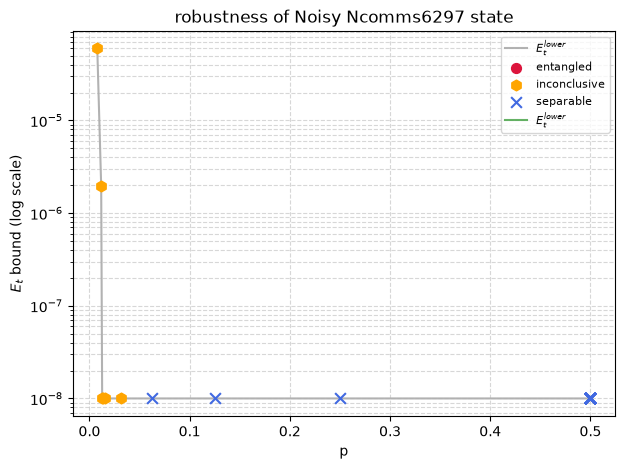

0it [00:00, ?it/s]


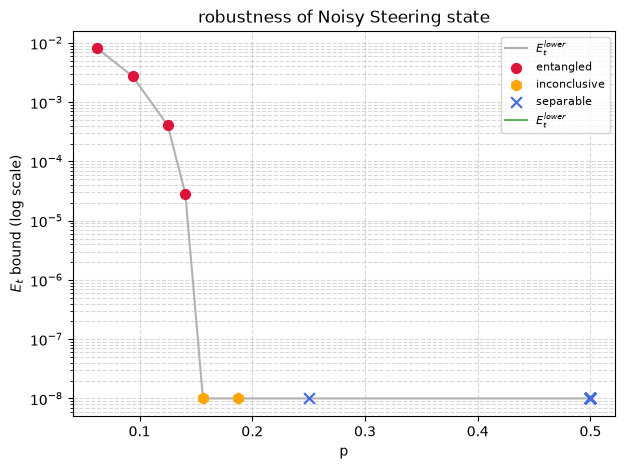

In [6]:
c3c3_non_parametric = [
    (chessboard_extremal_PPT(), "Chessboard"),
    (cross_hatch(), "Cross_hatch"),
    (tiles_upb(), "Tiles"),
    (pyramid_upb(), "Pyramid"),
    (ncomms6297(), "Ncomms6297"),
    (steering_state(0.4, 0.4), "Steering"),
]
maxmixed = max_mixed(3 * 3)

for state, name in c3c3_non_parametric:
    filename = f"{name}_with_noise_vertex.jsonl"
    bin_search_sdp_vertex(filename, (3, 3), [1, 1], lambda p: state * (1 - p) + maxmixed * p, (0, 1), 10, decreasing=True, folder="vertex")
    plot_robustness(filename, f"robustness of Noisy {name} state", "p", plot_upper=True, folder="vertex")

## Convex combinations of PPT states

0 points left to compute


0it [00:00, ?it/s]


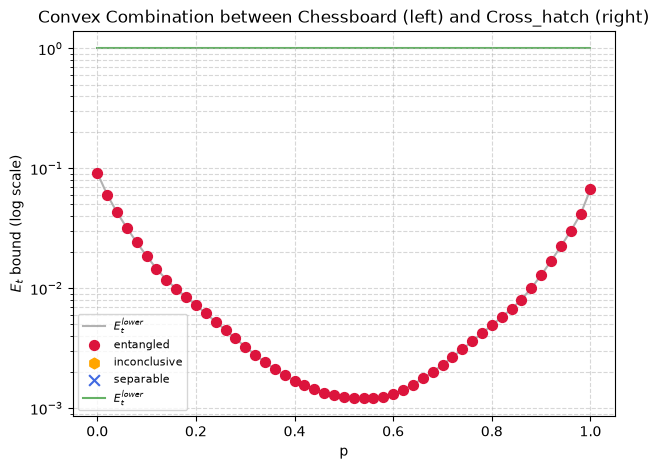

0 points left to compute


0it [00:00, ?it/s]


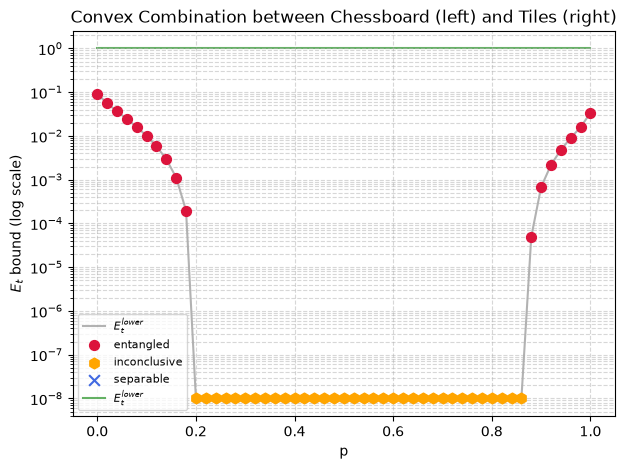

0 points left to compute


0it [00:00, ?it/s]


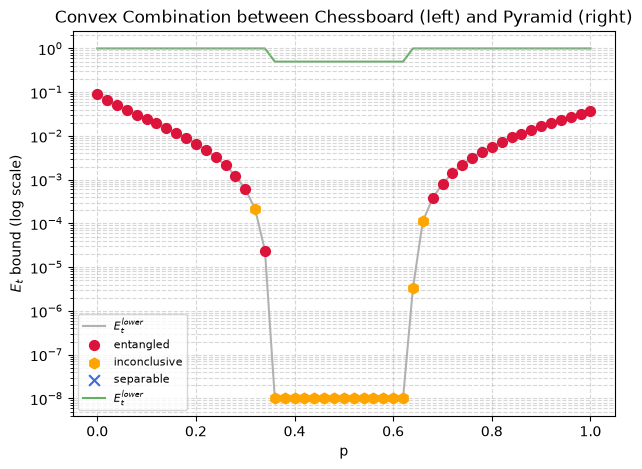

0 points left to compute


0it [00:00, ?it/s]


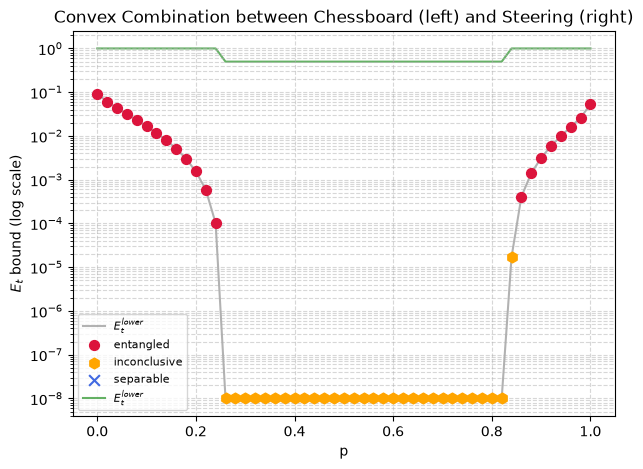

0 points left to compute


0it [00:00, ?it/s]


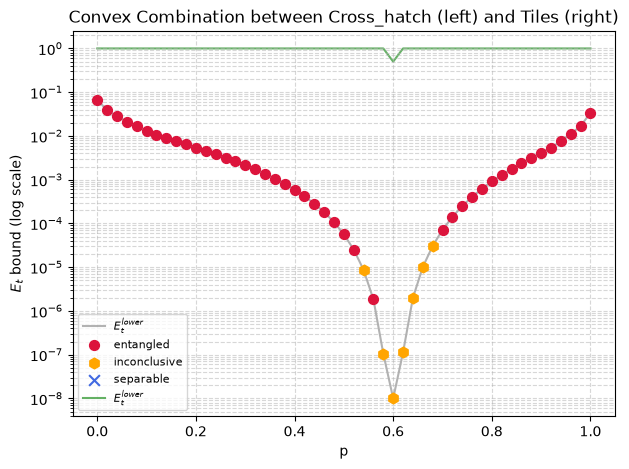

0 points left to compute


0it [00:00, ?it/s]


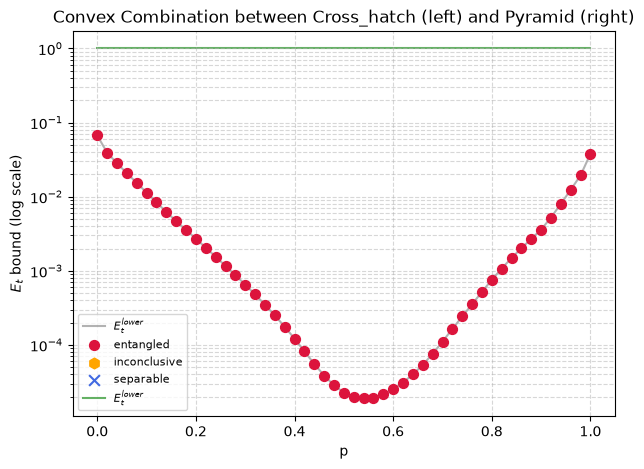

0 points left to compute


0it [00:00, ?it/s]


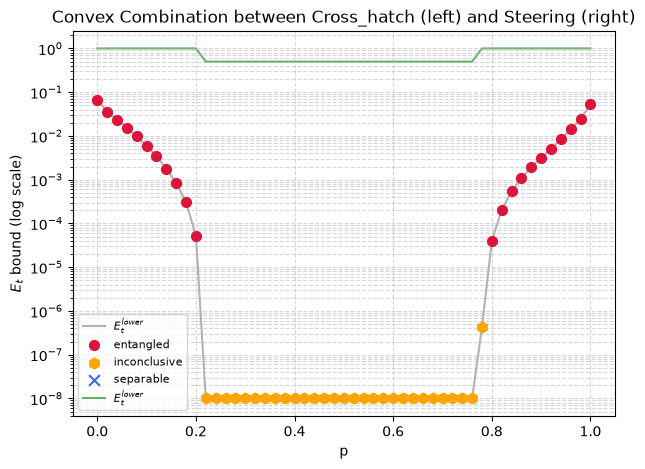

0 points left to compute


0it [00:00, ?it/s]


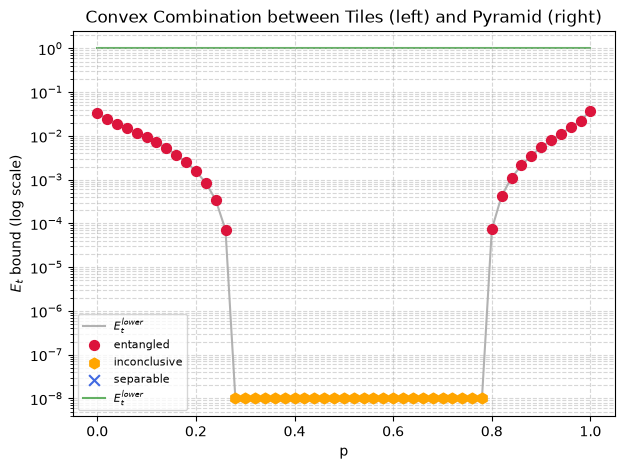

0 points left to compute


0it [00:00, ?it/s]


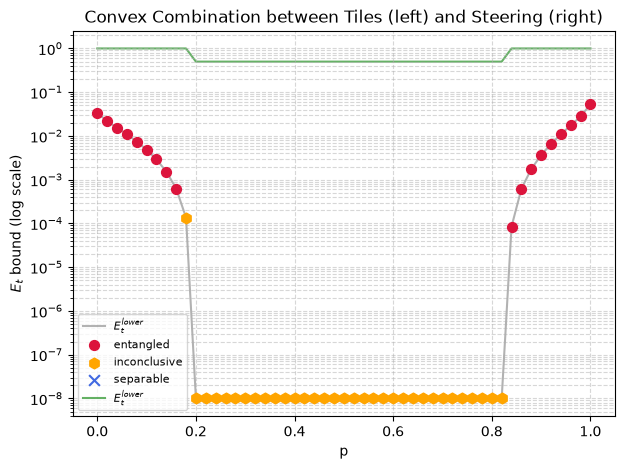

0 points left to compute


0it [00:00, ?it/s]


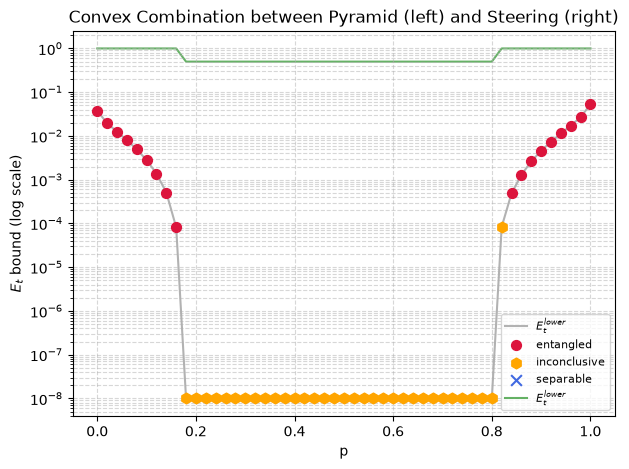

In [7]:
from itertools import combinations

c3c3_non_parametric = [
    (chessboard_extremal_PPT(), "Chessboard"),
    (cross_hatch(), "Cross_hatch"),
    (tiles_upb(), "Tiles"),
    (pyramid_upb(), "Pyramid"),
    (steering_state(0.4, 0.4), "Steering"),
]
for (st1, n1), (st2, n2) in combinations(c3c3_non_parametric, 2):
    filename = f"convex_{n1}_{n2}.jsonl"
    run_sdp_on_range(filename, (3, 3), [1, 1], lambda p: st1 * (1 - p) + st2 * p, range_, compute_upper=True, folder="convex", k_sym_depth=3)
    plot_robustness(filename, f"Convex Combination between {n1} (left) and {n2} (right)", "p", range_=range_, plot_upper=True, folder="convex")

# Test on $\mathbb{C}^3 \otimes \mathbb{C}^3$ states with noise and on Horodecki with lambda \[2,1\]

0 points left to compute


0it [00:00, ?it/s]


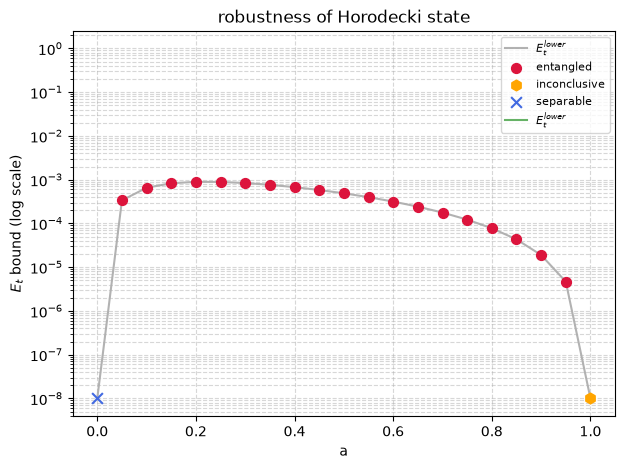

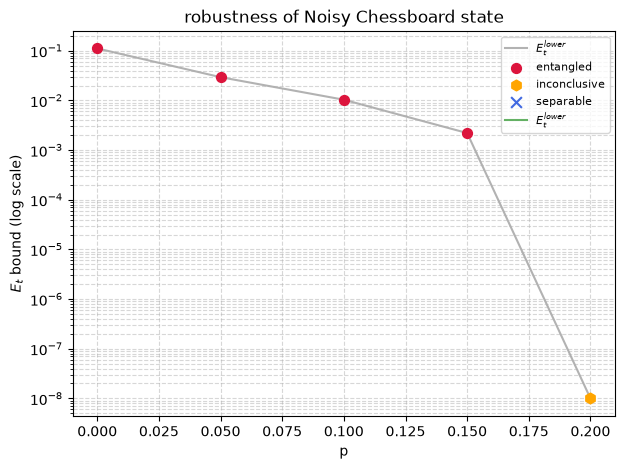

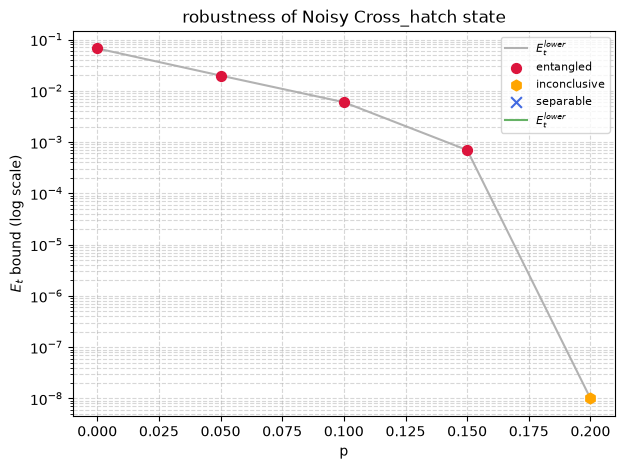

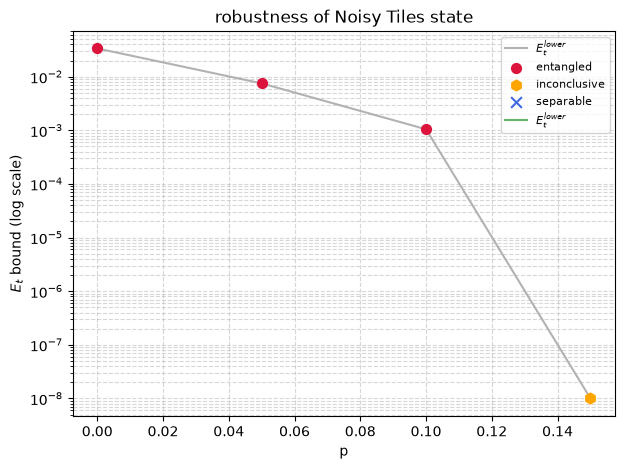

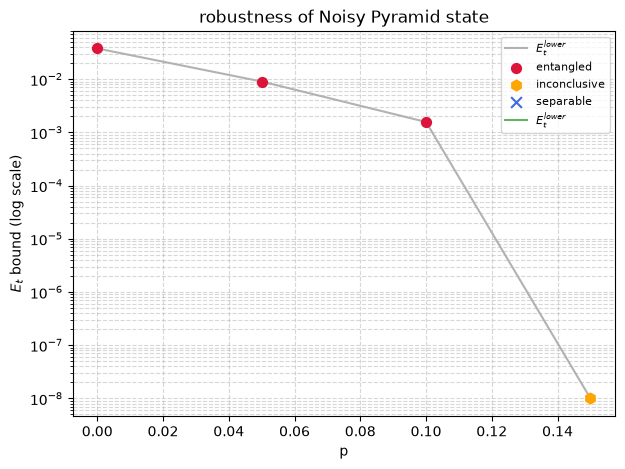

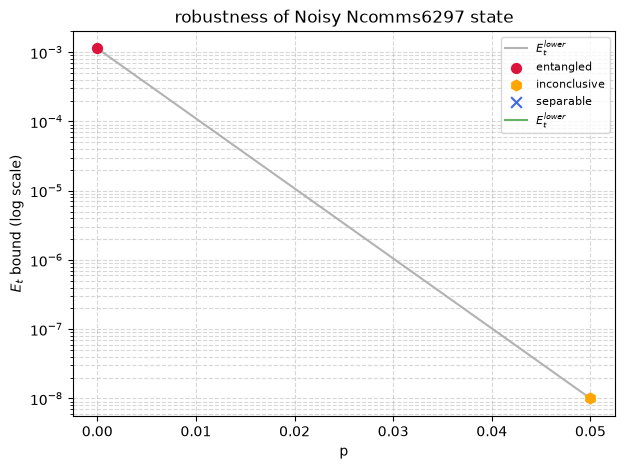

0 points left to compute


0it [00:00, ?it/s]


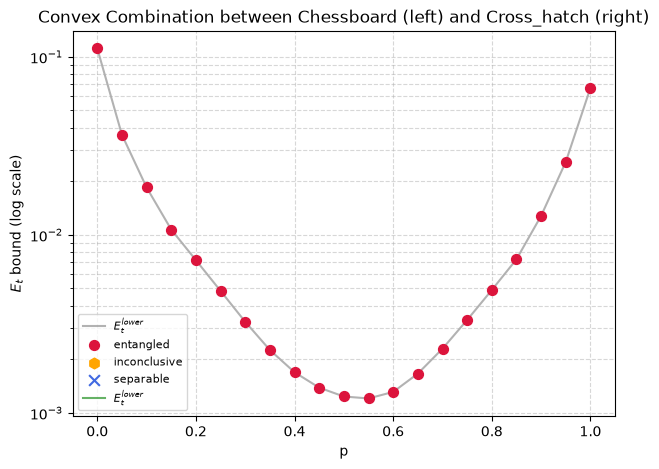

0 points left to compute


0it [00:00, ?it/s]


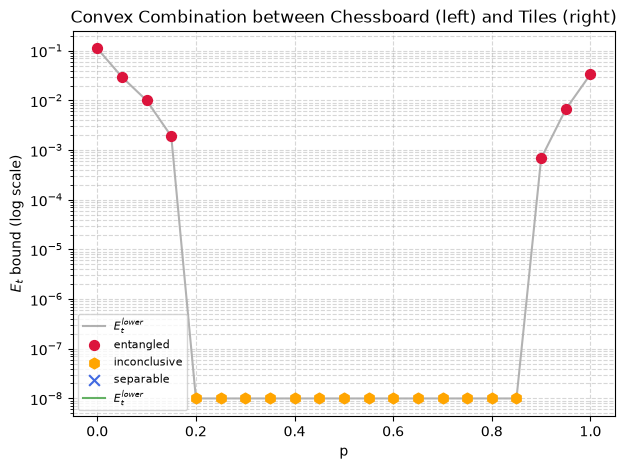

0 points left to compute


0it [00:00, ?it/s]


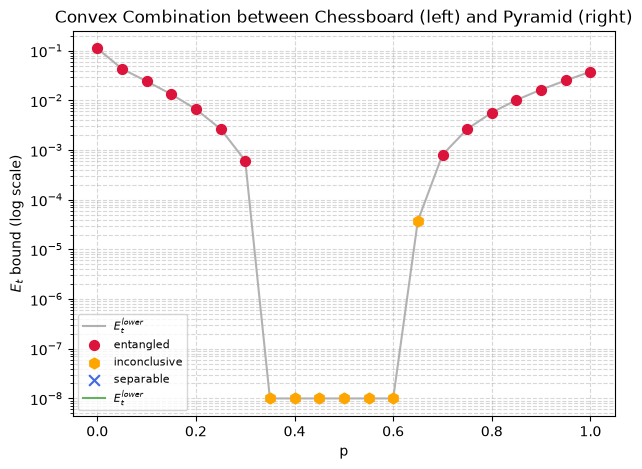

0 points left to compute


0it [00:00, ?it/s]


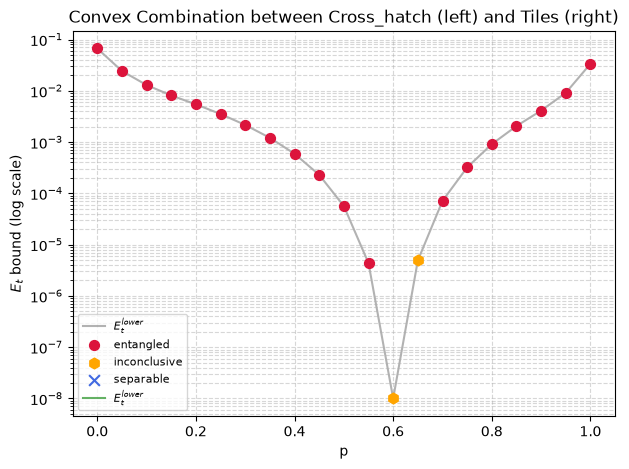

0 points left to compute


0it [00:00, ?it/s]


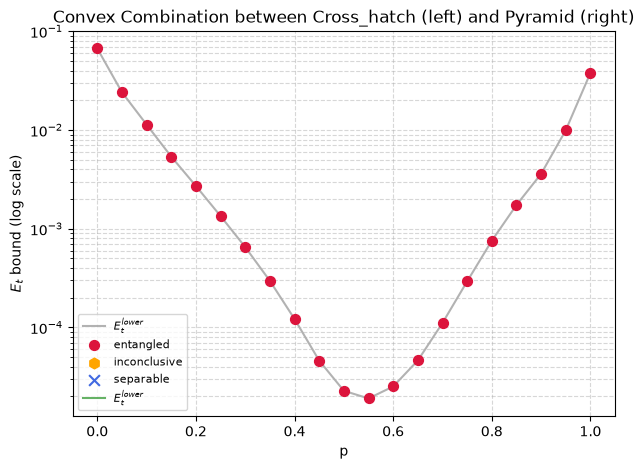

0 points left to compute


0it [00:00, ?it/s]


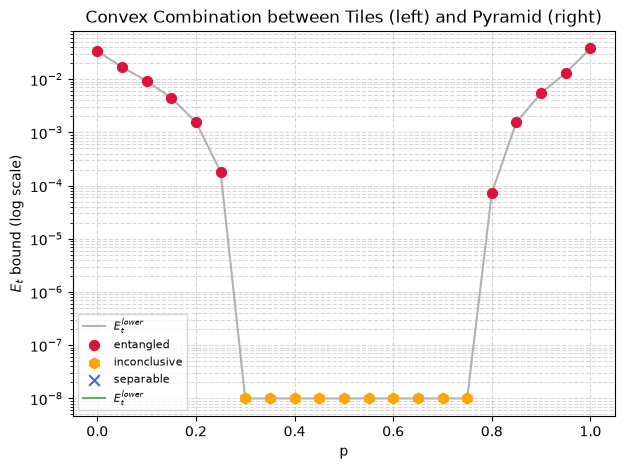

In [8]:
range_ = (0, 1, 0.1)
filename = "c3c3_Horodecki_lam21.jsonl"
range_ = (0, 1, 0.05)
run_sdp_on_range(filename, (3, 3), [2, 1], lambda p: horodecki(p), range_, compute_upper=True, folder="lam21")
plot_robustness(filename, "robustness of Horodecki state", "a", range_=range_, plot_upper=True, folder="lam21")


c3c3_non_parametric = [
    (chessboard_extremal_PPT(), "Chessboard"),
    (cross_hatch(), "Cross_hatch"),
    (tiles_upb(), "Tiles"),
    (pyramid_upb(), "Pyramid"),
    (ncomms6297(), "Ncomms6297"),
]
maxmixed = max_mixed(3 * 3)
for state, name in c3c3_non_parametric:
    filename = f"{name}_with_noise_lam21.jsonl"
    run_sdp_on_range(filename, (3, 3), [2, 1], lambda p: state * (1 - p) + maxmixed * p, range_, compute_upper=True, early_stop=True, folder="lam21")
    plot_robustness(filename, f"robustness of Noisy {name} state", "p", range_=range_, plot_upper=True, folder="lam21")

from itertools import combinations

c3c3_non_parametric = [(chessboard_extremal_PPT(), "Chessboard"), (cross_hatch(), "Cross_hatch"), (tiles_upb(), "Tiles"), (pyramid_upb(), "Pyramid")]
for (st1, n1), (st2, n2) in combinations(c3c3_non_parametric, 2):
    filename = f"convex_{n1}_{n2}_lam21.jsonl"
    run_sdp_on_range(filename, (3, 3), [2, 1], lambda p: st1 * (1 - p) + st2 * p, range_, compute_upper=True, folder="lam21")
    plot_robustness(filename, f"Convex Combination between {n1} (left) and {n2} (right)", "p", range_=range_, plot_upper=True, folder="lam21")

# Test on $\mathbb{C}^4 \otimes \mathbb{C}^4$ states with noise + Breur

0 points left to compute


0it [00:00, ?it/s]


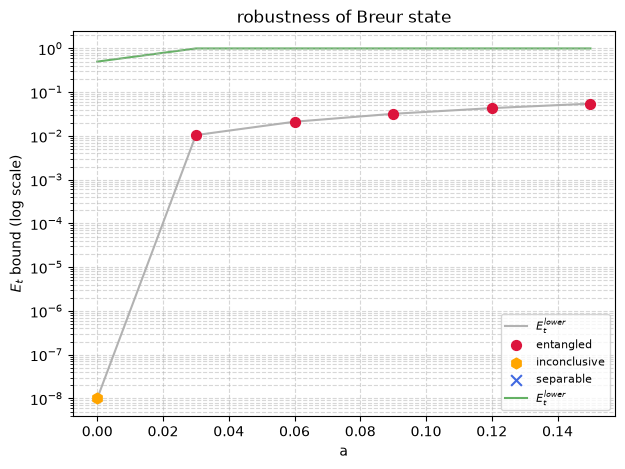

In [ ]:
from bound_entangled.c4_otimes_c4 import piani
from bound_entangled.cd_otimes_cd import gen_tiles1, yu_oh
from bound_entangled.cm_otimes_cn import gen_tiles2
from toqito.states import breuer

filename = "Breur.jsonl"
range_ = (0, 1/(4+2), 0.03)
run_sdp_on_range(filename, (4, 4), [1, 1], lambda p: breuer(4, p), range_, compute_upper=True, folder="Parametric")
plot_robustness(filename, "robustness of Breur state", "a", range_=range_, plot_upper=True, folder="Parametric")

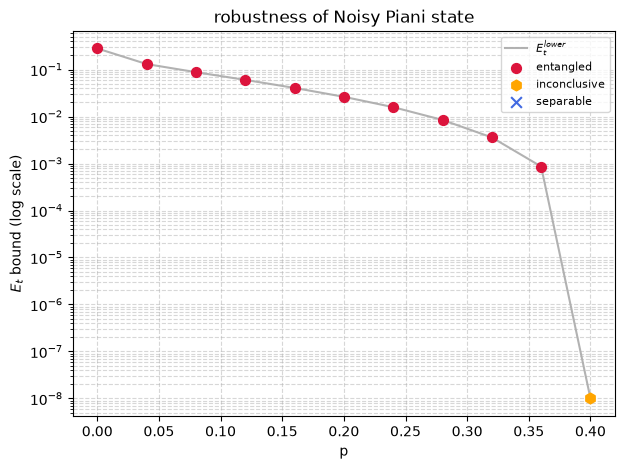

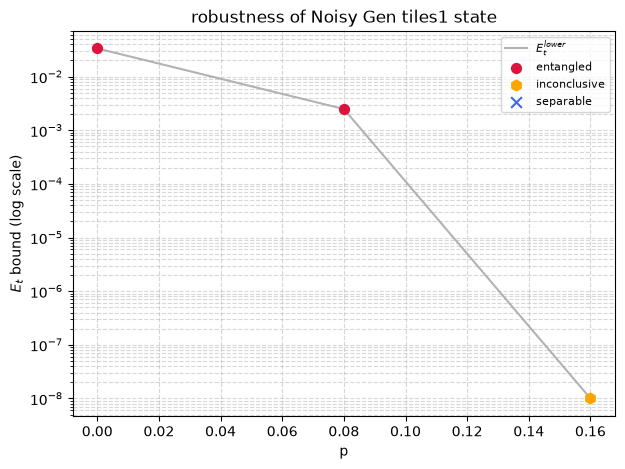

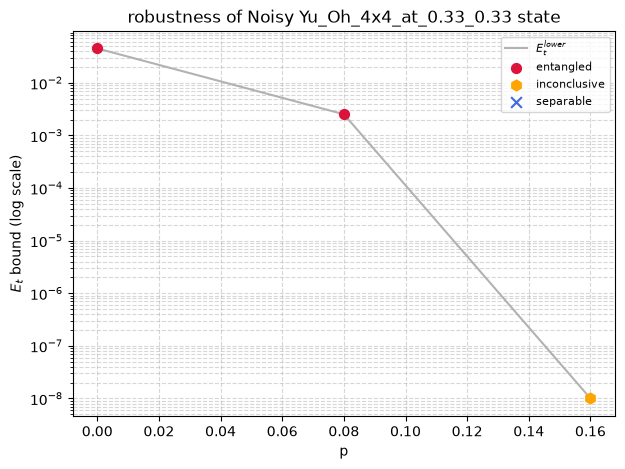

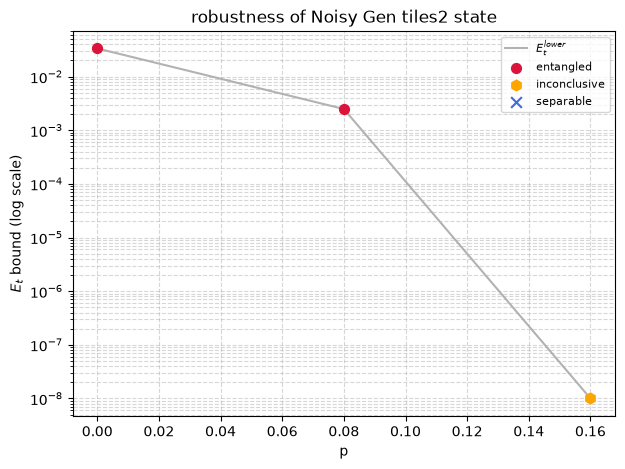

In [10]:
range_ = (0, 1, 0.04)
c4c4_states: list[tuple[np.ndarray, str]] = [
    (piani(), "Piani"),
    (gen_tiles1(full_dim=4), "Gen tiles1"),
    (yu_oh(full_dim=4, x=1 / 3, y=1 / 3), "Yu_Oh_4x4_at_0.33_0.33"),
    (gen_tiles2((4, 4)), "Gen tiles2"),
]
maxmixed = max_mixed(4 * 4)
for state, name in c4c4_states:
    filename = f"{name}_with_noise.jsonl"
    run_sdp_on_range(filename, (4, 4), [1, 1], lambda p: state * (1 - p) + maxmixed * p, range_, compute_upper=True, early_stop=True, folder="noise")
    plot_robustness(filename, f"robustness of Noisy {name} state", "p", range_=range_, folder="noise")

# Test on $\mathbb{C}^3 \otimes \mathbb{C}^3$ Isotropic state.

According to https://arxiv.org/pdf/quant-ph/9911117 theorem 2
$$SN(\rho) = k \iff \frac{k-1}{d} < F < \frac{k}{d}$$

$$\text{SN}(\rho_F) = \begin{cases} 
1 & 0 \le F \le \tfrac{1}{3} \quad (\text{separable})\\
2 & \tfrac{1}{3} < F \le \tfrac{2}{3}\\
3 & \tfrac{2}{3} < F \le 1 
\end{cases}$$

0it [00:00, ?it/s]


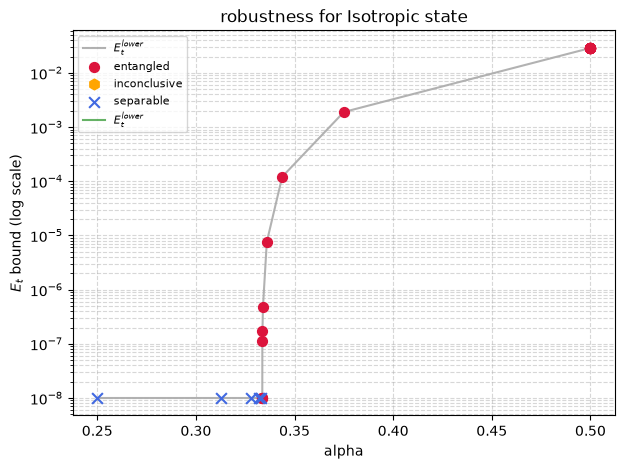

0it [00:00, ?it/s]


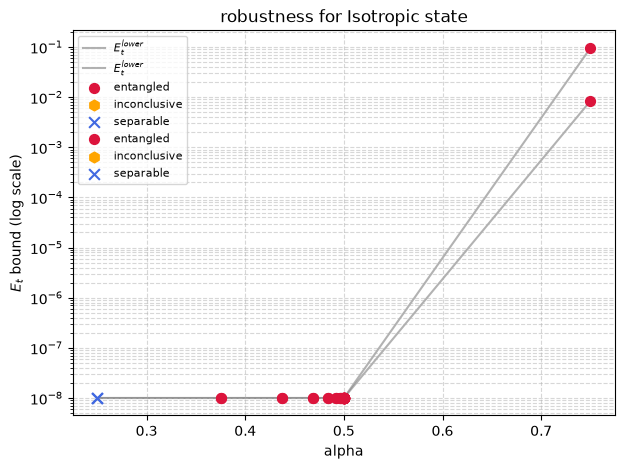

In [11]:
from toqito.states import isotropic as isoA


def isotropic(F):
    alpha = (9 * F - 1) / 8
    return isoA(3, alpha)


filename = "c3c3_isotropicSN2_bin.jsonl"
bin_search_sdp_vertex(filename, (3, 3), [1, 1], lambda F: isotropic(F),(0,1), 15, folder="test")
plot_robustness(filename, "robustness for Isotropic state", "alpha", plot_upper=True, folder="test")

filename = "c3c3_isotropicSN3_bin.jsonl"
bin_search_sdp_vertex(filename, (3, 3), [1, 1, 1], lambda F: isotropic(F),(0,1), 10, folder="SN3")
plot_robustness(filename, "robustness for Isotropic state", "alpha", plot_upper=False, folder="SN3")

In [ ]:
from tavako import tavakoli_morelli_state

filename = "tavakoli_bin.jsonl"
bin_search_sdp_vertex(filename, (3, 3), [1, 1, 1], lambda q: tavakoli_morelli_state(q), (0,1), 15, folder="SN3")
plot_robustness(filename, "robustness for tavakoli state", "alpha",plot_upper= False, folder="SN3")